# Classification Problem - Predicting Customer Churn

## Goal
Predict whether a customer will churn (discontinue their subscription) based on their demographics, usage patterns, and engagement metrics, using supervised learning classification models.

## Data Preparation

### Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

from joblib import dump, load

### Paths

Centralize the data and model directories so every read/write below resolves through these constants.

In [2]:
from pathlib import Path

DATA_DIR = Path("data")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

### Loading the Dataset

In [3]:
df = pd.read_csv(DATA_DIR / "customer_churn_dataset.csv")
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [4]:
df.shape

(64374, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


### Step 1 - Removing Meaningless Columns

**`CustomerID`** — This column is a unique identifier assigned to each customer. It carries no predictive value for whether a customer will churn; two customers with identical behavior but different IDs should produce the same prediction. Leaving it in could also cause the model to overfit to specific ID values. We drop it.

In [6]:
df = df.drop('CustomerID',axis=1)

In [7]:
print(f"Null count:{df.isnull().sum().sum()}")
print(f"NA count:{df.isna().sum().sum()}")
print(f"Duplicated count:{df.duplicated().sum()}")

Null count:0
NA count:0
Duplicated count:0


### Step 2 & 3 - Handling Missing Values and Removing Duplicates

**Missing values:** The dataset contains no null or NA values across any column, so no imputation or removal is needed.

**Duplicates:** The dataset contains no duplicate rows, so no deduplication is needed.

If either of these checks had failed, we would have dropped the affected rows rather than impute — with over 64,000 records we can afford to lose a few, and imputing churn-related behavioral features (e.g., Support Calls, Payment Delay) with column means could introduce misleading signals.

In [8]:
df = pd.get_dummies(df,drop_first=True)

### Step 4 - Converting Categorical Features

Three features are categorical: `Gender`, `Subscription Type`, and `Contract Length`. We convert them to numerical form using `pd.get_dummies` with `drop_first=True` to avoid the dummy variable trap (perfect multicollinearity between the one-hot encoded columns).

## Data Exploration

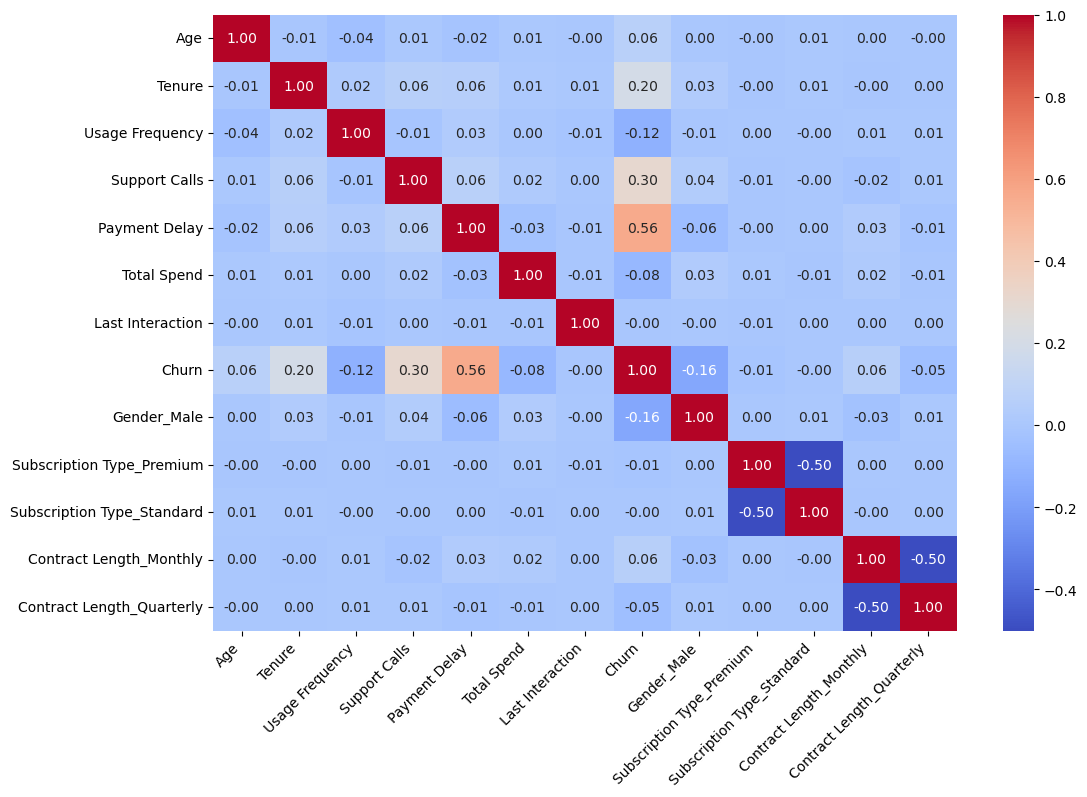

In [9]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.xticks(rotation=45, ha='right')
plt.show()

### Correlation Insights

**Features strongly correlated with `Churn`:**
- **Support Calls (+)** — customers who repeatedly contact support are likely experiencing issues or dissatisfaction, which pushes them toward leaving.
- **Payment Delay (+)** — frequent late payments signal financial friction or weakening engagement with the service, both of which precede churn.
- **Usage Frequency (−)** — the more often a customer uses the service, the more value they derive from it, so they are less likely to cancel.

**Features weakly correlated with `Churn`:**
- Age, Tenure, Total Spend, Last Interaction, and Gender all show relatively weak individual correlations with the label. They may still contribute predictive value in combination with other features, but on their own they are not strong indicators.

**Feature-to-feature correlations:**
- `Subscription Type_Standard` ↔ `Subscription Type_Premium` and `Contract Length_Monthly` ↔ `Contract Length_Quarterly` show negative correlations. This is **not a real relationship** — it is a mechanical artifact of one-hot encoding: since a customer can only belong to one category at a time, the dummy variables are mutually exclusive and therefore negatively correlated by construction. Using `drop_first=True` already mitigates part of this.
- No other strong feature-to-feature correlations are observed, which means multicollinearity is not a major concern for our models.

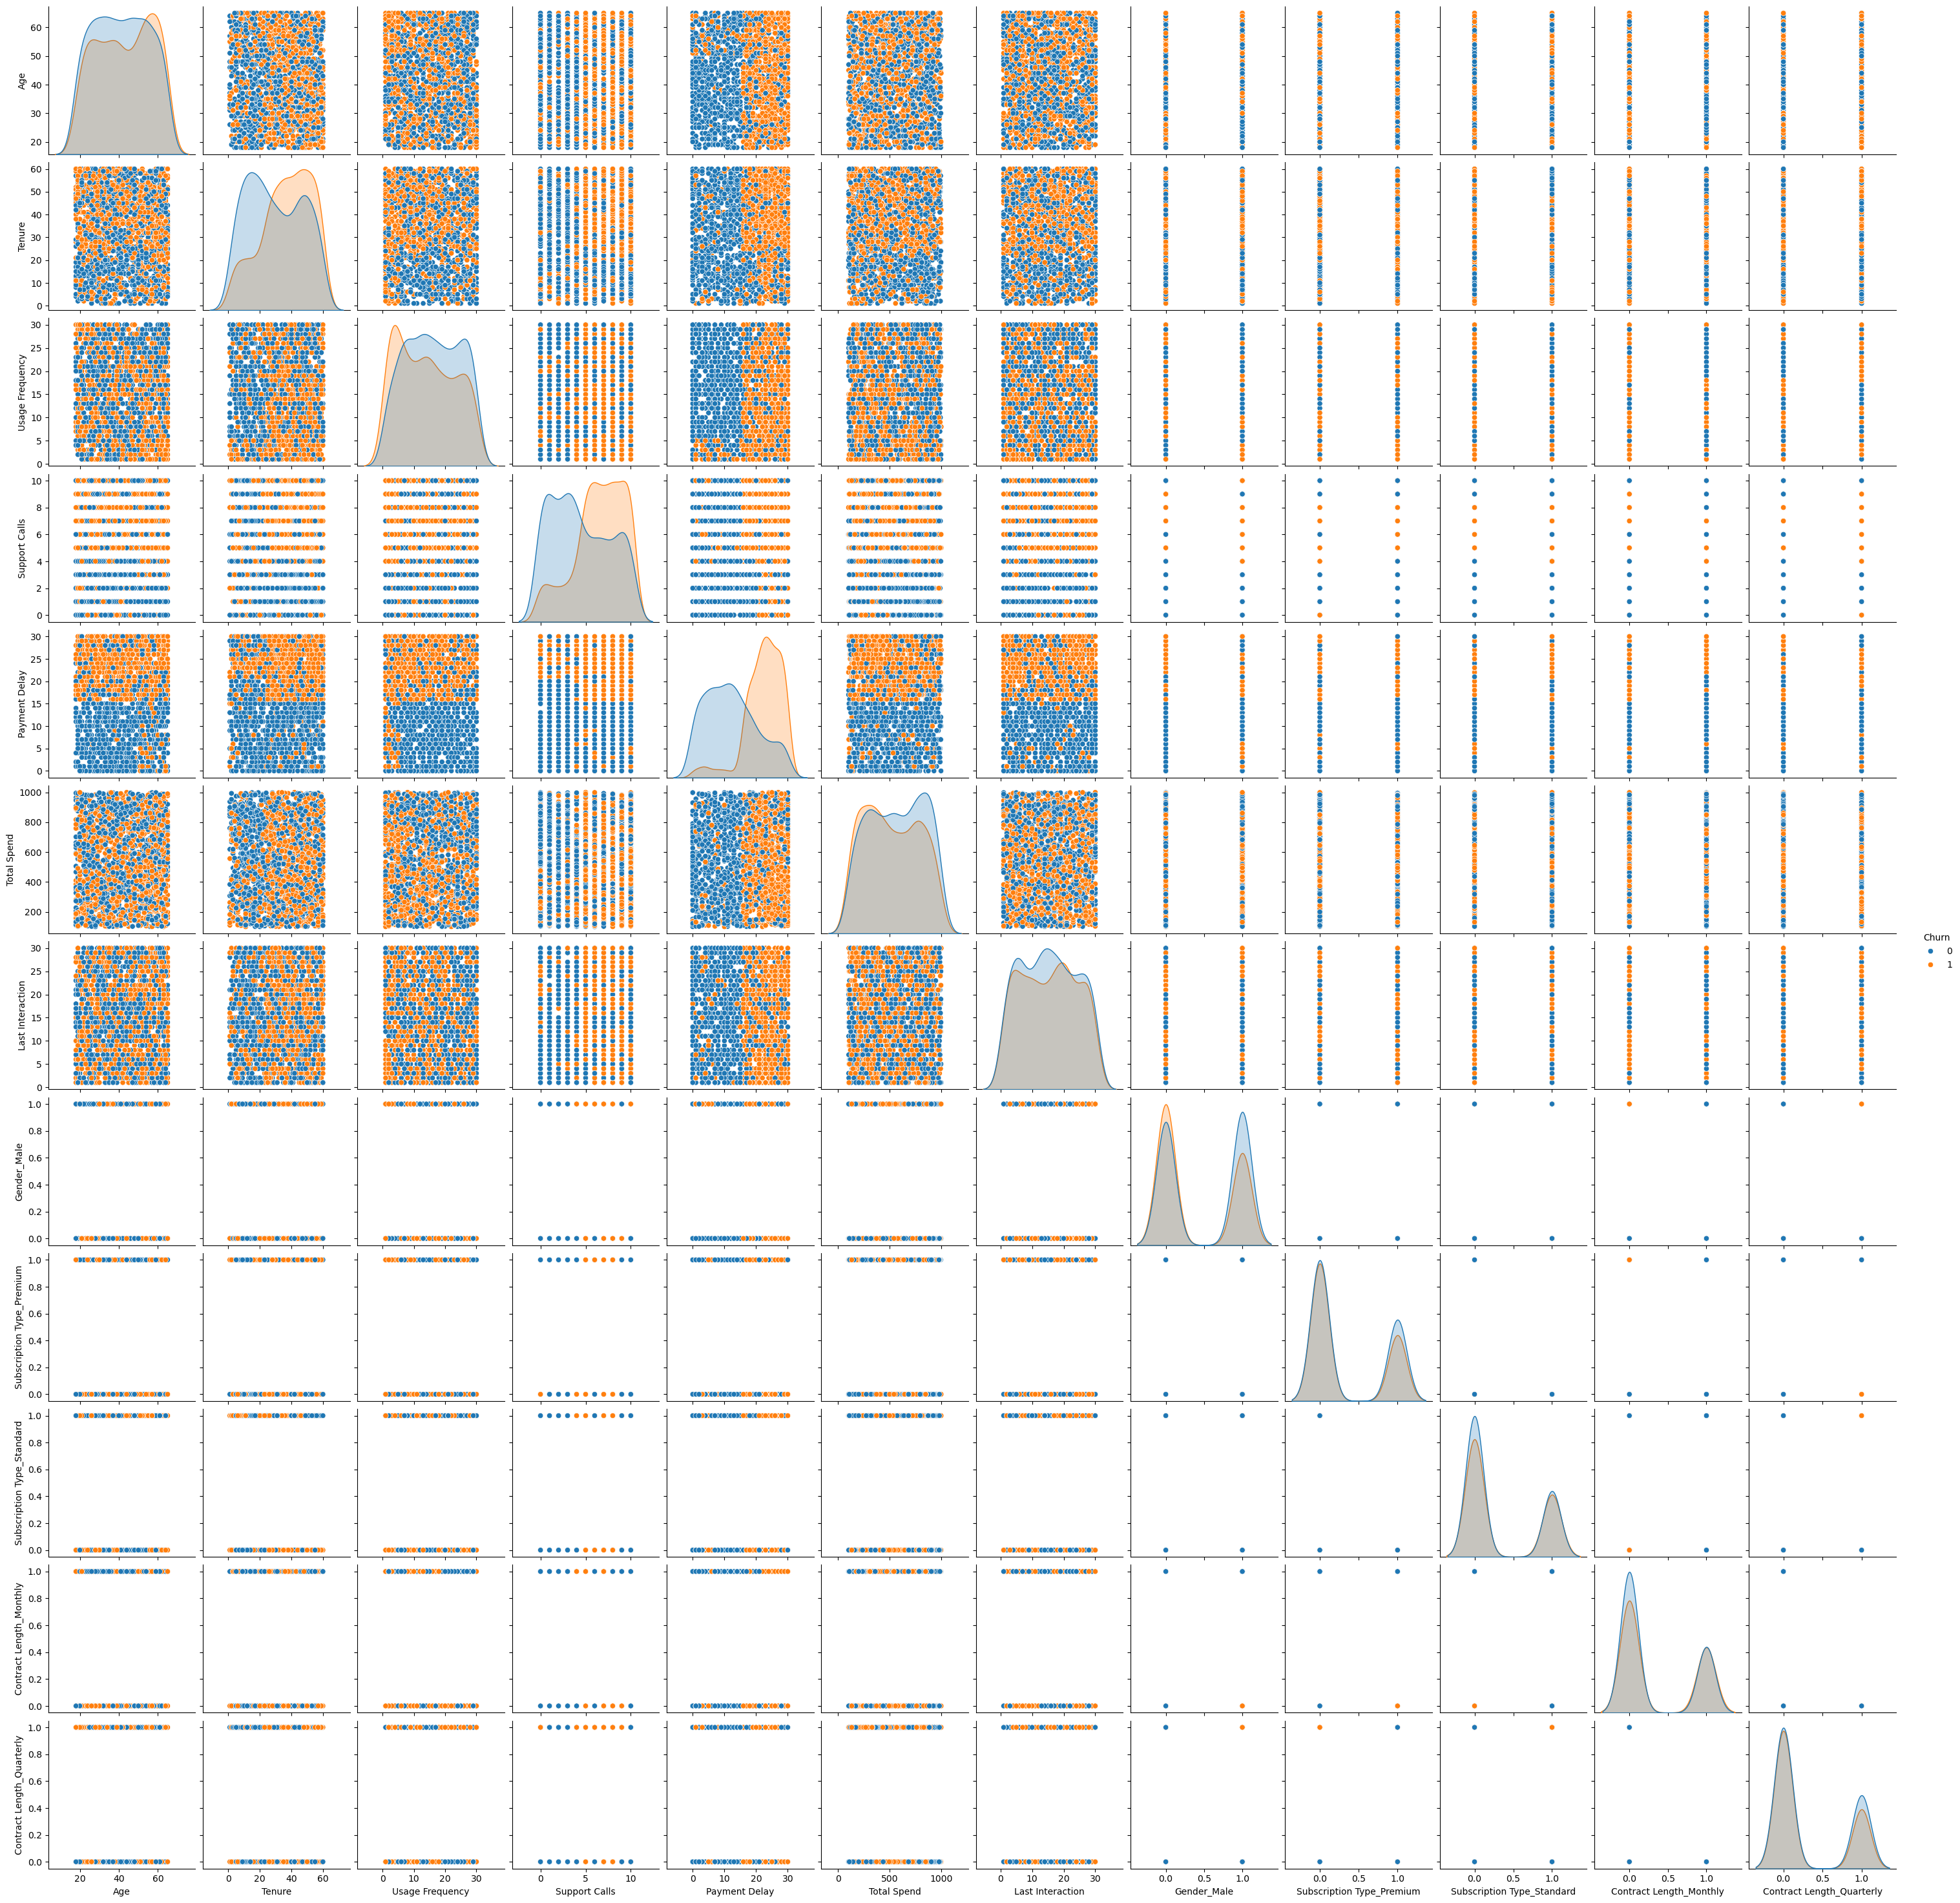

In [10]:
sns.pairplot(df.sample(2000,random_state=42),hue='Churn')

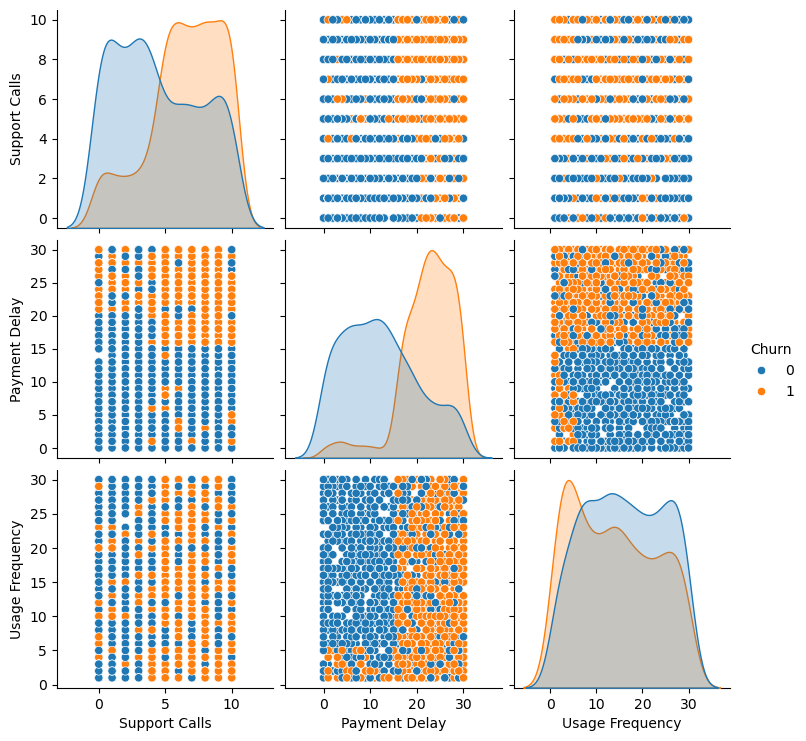

In [11]:
sns.pairplot(df[['Support Calls','Payment Delay','Usage Frequency','Churn']].sample(2000, random_state=42), hue='Churn')

### Pairplot Insights

Focusing on the three features most correlated with `Churn` (Support Calls, Payment Delay, Usage Frequency):

- **Support Calls** — the diagonal distribution shows a clear shift: churned customers (class 1) are concentrated at higher values of support calls, while retained customers cluster at lower values. This strongly supports the idea that repeated support contact is a reliable churn indicator.
- **Payment Delay** — a similar separation is visible. Churned customers skew toward higher payment delays, while retained customers are more evenly spread with a bias toward lower delays.
- **Usage Frequency** — the separation is weaker and the two classes overlap heavily, though retained customers slightly tilt toward higher usage. On its own this feature is less discriminative than the two above.

- **Feature-to-feature scatter plots** show no obvious linear relationships between these three features. That is a good sign for modeling: they each carry largely independent information about churn, so including all of them should help the model rather than introduce redundancy.

Overall, Support Calls and Payment Delay appear to be the most powerful single predictors of churn, with Usage Frequency providing weaker but still useful complementary signal.

## Model Training

### Setup

- **Feature scaling:** StandardScaler (standardization), fit on training data only
- **Train/test split:** `test_size=0.3`, `random_state=42`
- **Evaluation metrics:** Accuracy, Recall, F1-Score + confusion matrix heatmap
- **Per-model probabilities:** Captured where the model provides `predict_proba`

### Helper — `evaluate_model`

To avoid repeating the same evaluation logic for every model, we define a single helper that prints predictions + probabilities, computes all three metrics, plots the confusion matrix, and stores results in a shared dict for later comparison.

In [12]:
def evaluate_model(model, model_name, X_test, y_test, results_dict):
    y_pred = model.predict(X_test)
    if y_pred.ndim > 1 or not np.array_equal(np.unique(y_pred), [0, 1]):
        y_pred = (y_pred.ravel() > 0.5).astype(int)

    
    # Probabilities (only if model supports it)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)
        proba_df = pd.DataFrame(y_proba, columns=['P(No Churn)', 'P(Churn)'])
        proba_df['Prediction'] = y_pred
        print(f"\n--- {model_name}: Predictions & Probabilities (first 10) ---")
        print(proba_df.head(10))
    else:
        print(f"\n--- {model_name}: Predictions (first 10) ---")
        print(y_pred[:10])
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    print(f" \n{model_name} Metrics:\nAccuracy: {acc:.4f}\nRecall: {rec:.4f}\nF1: {f1:.4f}")
    
    # Confusion matrix heatmap
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Churn','Churn'], yticklabels=['No Churn','Churn'])
    plt.title(f'{model_name} — Confusion Matrix')
    plt.xlabel('Predicted'); plt.ylabel('Actual')
    plt.show()
    
    # Store for comparison table
    results_dict[model_name] = {'Accuracy': acc, 'Recall': rec, 'F1-Score': f1}
    return y_pred


In [13]:
results_df = {}

### Train / Test Split & Standardization

We separate the features (`X`) from the label (`Churn`), then split into train/test with `test_size=0.3` and `random_state=42` as required.

Standardization is applied **only** after the split: the scaler is fit on the training set and then used to transform both the training and test sets. This prevents information from the test set from leaking into training.

Scaling is required because the features have very different ranges (e.g. `Age` ~20–60 vs `Total Spend` ~100–1000), and distance/gradient-based models such as Logistic Regression, KNN, and SVM are sensitive to feature scale. Random Forest does not require scaling, but we will still use the scaled data for consistency.

In [14]:
X = df.drop("Churn",axis=1)
y = df['Churn']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
)

scaler = StandardScaler()
scaled_x_train = scaler.fit_transform(X_train)
scaled_x_test = scaler.transform(X_test)

### 1. Logistic Regression

We use `LogisticRegressionCV` with 5-fold cross-validation to automatically find the optimal regularization strength `C`. We use L1 penalty (via the `saga` solver) so that irrelevant features can be pushed to zero. The `Cs` grid searches a wide logarithmic range of values.

In [16]:
log_model = LogisticRegressionCV(
    cv=5, max_iter=5000, solver="saga", penalty="l1", Cs=np.logspace(0, 4, 10)
)
log_model.fit(scaled_x_train,y_train)

c:\Users\Adir\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\Adir\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\Adir\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior no

,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",array([1.0000...00000000e+04])
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_selection` module for thelist of possible cross-validation objects... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer dual=False whenn_samples > n_features.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet'}, default='l2'Specify the norm of the penalty:- `'l2'`: add a L2 penalty term (used by default);- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"scoring scoring: str or callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: :ref:`accuracy ` is used.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' might be slower in :class:`LogisticRegressionCV` because it does not handle warm-starting.- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme fo

In [17]:
print(f"Optimal C: {log_model.C_[0]}")

Optimal C: 1.0


Conclusion: **C = 1.0** is the optimal regularization strength.


--- Logistic Regression: Predictions & Probabilities (first 10) ---
   P(No Churn)  P(Churn)  Prediction
0     0.986552  0.013448           0
1     0.996329  0.003671           0
2     0.139802  0.860198           1
3     0.831043  0.168957           0
4     0.354999  0.645001           1
5     0.811019  0.188981           0
6     0.982283  0.017717           0
7     0.983644  0.016356           0
8     0.431951  0.568049           1
9     0.986341  0.013659           0
 
Logistic Regression Metrics:
Accuracy: 0.8289
Recall: 0.8260
F1: 0.8211


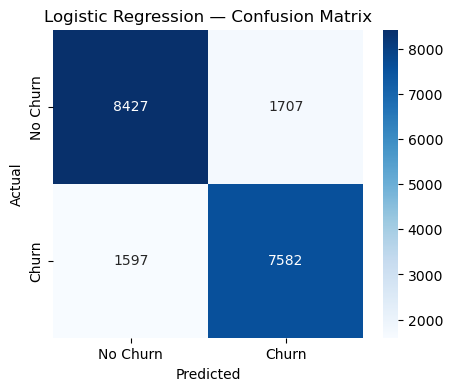

In [18]:
y_predictions = evaluate_model(log_model,"Logistic Regression",scaled_x_test,y_test,results_df)

### 2. K Nearest Neighbors

To find the optimal number of neighbors `K`, we use the **elbow method**: we train KNN for a range of K values and track the test error for each. The optimal K is the one that minimizes the error — or the point where the curve starts to flatten out.

In [19]:
test_error_rates = []

for k in range(1, 12):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(scaled_x_train, y_train)

    y_pred_test = knn_model.predict(scaled_x_test)
    test_error = 1 - accuracy_score(y_test, y_pred_test)
    test_error_rates.append(test_error)

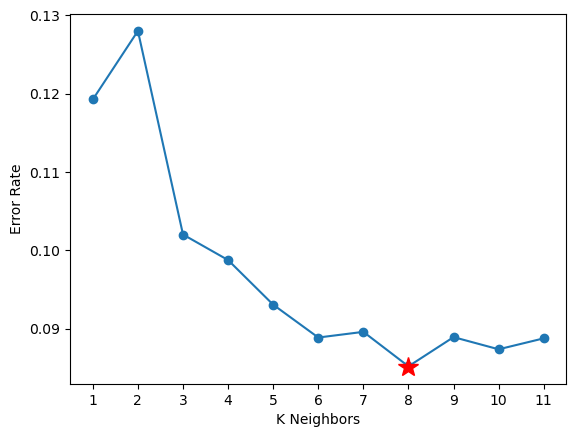

In [20]:
plt.plot(range(1,12), test_error_rates, marker='o')
plt.plot(8, 0.0851, marker='*', color='red', markersize=15)
plt.xticks(range(1,12))
plt.ylabel('Error Rate')
plt.xlabel('K Neighbors')
plt.show()

Conclusion: **K = 8** is the optimal number of neighbors — it produces the lowest test error rate in the range we tested.

In [21]:
knn_model = KNeighborsClassifier(n_neighbors=8)
knn_model.fit(scaled_x_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",8
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None



--- K Nearest Neighbors: Predictions & Probabilities (first 10) ---
   P(No Churn)  P(Churn)  Prediction
0        1.000     0.000           0
1        1.000     0.000           0
2        0.375     0.625           1
3        1.000     0.000           0
4        0.125     0.875           1
5        0.375     0.625           1
6        1.000     0.000           0
7        1.000     0.000           0
8        0.125     0.875           1
9        1.000     0.000           0
 
K Nearest Neighbors Metrics:
Accuracy: 0.9148
Recall: 0.9150
F1: 0.9108


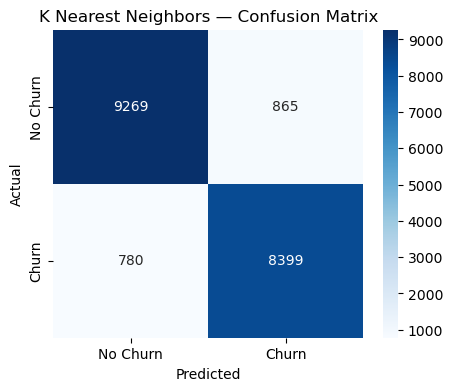

In [22]:
y_predictions = evaluate_model(knn_model,"K Nearest Neighbors",scaled_x_test,y_test,results_df)


### 3. SVM

For SVM we use `GridSearchCV` over `C` and `kernel`. Since SVC scales roughly O(n²) with dataset size and our training set has ~45k rows, we tune the hyperparameters on a stratified 5k sample, then refit the best model on the full training set. We pass `probability=True` on the final model so we can output per-class probabilities (required by the assignment).

In [23]:
X_sample, _, y_sample, _ = train_test_split(
    scaled_x_train, y_train, 
    train_size=5000,        # 5k rows is plenty for tuning
    stratify=y_train, 
    random_state=42
)

In [24]:
param_grid = {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}
svm_grid = GridSearchCV(SVC(), param_grid, cv=5)
svm_grid.fit(X_sample, y_sample)

print(f"Best params: {svm_grid.best_params_}")

Best params: {'C': 10, 'kernel': 'rbf'}


Conclusion: **C = 10** with the **rbf** kernel is the optimal combination.

In [25]:
svm_model = SVC(**svm_grid.best_params_, probability=True)
svm_model.fit(scaled_x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False



--- SVC: Predictions & Probabilities (first 10) ---
    P(No Churn)      P(Churn)  Prediction
0  9.999998e-01  2.016061e-07           0
1  9.999981e-01  1.876529e-06           0
2  6.666763e-01  3.333237e-01           0
3  9.999987e-01  1.269950e-06           0
4  1.912664e-01  8.087336e-01           1
5  8.634060e-02  9.136594e-01           1
6  9.999915e-01  8.545798e-06           0
7  9.999997e-01  2.614593e-07           0
8  8.303871e-07  9.999992e-01           1
9  9.999989e-01  1.141462e-06           0
 
SVC Metrics:
Accuracy: 0.9523
Recall: 0.9607
F1: 0.9503


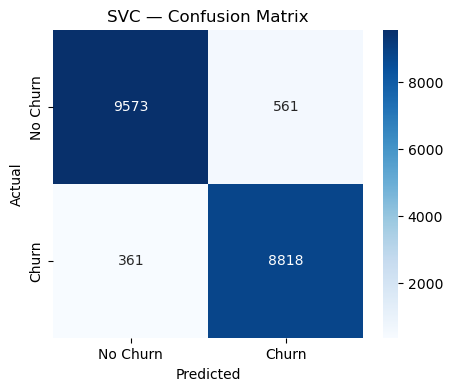

array([0, 0, 0, ..., 0, 1, 1], shape=(19313,))

In [26]:
evaluate_model(svm_model,"SVC",scaled_x_test,y_test,results_df)

### 4. Random Forest

For Random Forest we use `GridSearchCV` to tune the individual-tree parameters (`max_features`, `max_depth`) alongside the forest-level parameters (`n_estimators`, `bootstrap`). As with SVM, we tune on a 10k stratified sample for speed and refit the best parameters on the full training set. Note that Random Forest does **not** require feature scaling — trees split on raw feature values — so we pass the unscaled `X_train` / `X_test`.

In [27]:
X_rf_sample, _, y_rf_sample, _ = train_test_split(
    X_train, y_train,
    train_size=10000,
    stratify=y_train,
    random_state=42
)

In [28]:
param_grid = {
    "n_estimators": [100, 200],
    "max_features": ['sqrt', 3, 4],
    "bootstrap": [True],           # keep True so oob is valid
    "max_depth": [None, 20],
}

rfc = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(rfc, param_grid, cv=3, n_jobs=-1)
grid.fit(X_rf_sample, y_rf_sample)

print(f"Best params: {grid.best_params_}")

Best params: {'bootstrap': True, 'max_depth': None, 'max_features': 4, 'n_estimators': 100}


Conclusion: `n_estimators=100`, `max_features=4`, `max_depth=None`, `bootstrap=True` is the optimal combination.

In [29]:
rf_model = RandomForestClassifier(**grid.best_params_, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)   # RF doesn't need scaled data — use raw X_train

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr


--- Random Forest: Predictions & Probabilities (first 10) ---
   P(No Churn)  P(Churn)  Prediction
0         1.00      0.00           0
1         1.00      0.00           0
2         0.01      0.99           1
3         1.00      0.00           0
4         0.96      0.04           0
5         0.99      0.01           0
6         1.00      0.00           0
7         1.00      0.00           0
8         0.00      1.00           1
9         1.00      0.00           0
 
Random Forest Metrics:
Accuracy: 0.9988
Recall: 0.9981
F1: 0.9987


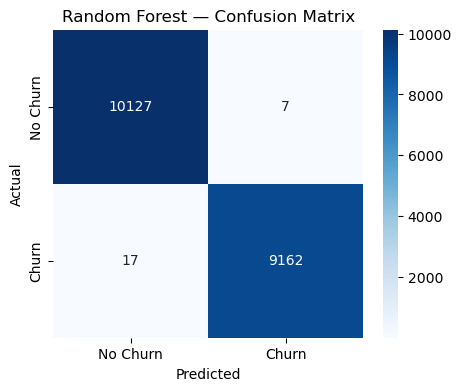

array([0, 0, 1, ..., 0, 1, 1], shape=(19313,))

In [30]:
evaluate_model(rf_model,"Random Forest",X_test,y_test,results_df)

## Bonus - Artificial Neural Network

In [31]:
print(scaled_x_train.shape)

(45061, 12)


Tensorflow is imported only in this bonus section so the main notebook above runs without a TF installation.

In [32]:
import tensorflow as tf

In [33]:
def train_ann(activation):
    ann = tf.keras.models.Sequential()

    # First layer - Input layer
    ann.add(tf.keras.layers.Input(shape=(12,)))

    # Second layer - Hidden layer
    ann.add(tf.keras.layers.Dense(units=10,activation=activation))

    # Last layer - Output layer
    ann.add(tf.keras.layers.Dense(units=1,activation='sigmoid'))

    ann.compile(optimizer='sgd',loss='binary_crossentropy',metrics=['accuracy'])
    
    ann.fit(scaled_x_train,y_train,batch_size=32,epochs=100)
    
    evaluate_model(ann,f"Ann - ({activation})",scaled_x_test,y_test,results_df)
    

Epoch 1/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 2s 794us/step - accuracy: 0.7302 - loss: 0.5413
Epoch 2/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.8315 - loss: 0.3827
Epoch 3/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.8468 - loss: 0.3480
Epoch 4/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - accuracy: 0.8560 - loss: 0.3261
Epoch 5/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 780us/step - accuracy: 0.8642 - loss: 0.3094
Epoch 6/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.8704 - loss: 0.2966
Epoch 7/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - accuracy: 0.8755 - loss: 0.2860
Epoch 8/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 835us/step - accuracy: 0.8809 - loss: 0.2769
Epoch 9/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 838us/step - accuracy: 0.8847 - loss: 0.2686
Epoch 10/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 848us/step - accuracy: 0.8881 - loss: 0.2611
Epoch 11/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step - accuracy: 0.8900 - loss: 0.25

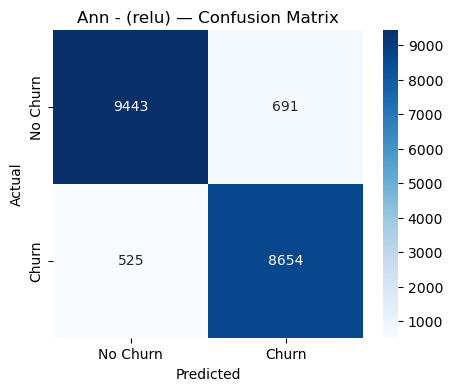

Epoch 1/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.7802 - loss: 0.4683
Epoch 2/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.8281 - loss: 0.3852
Epoch 3/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 796us/step - accuracy: 0.8311 - loss: 0.3745
Epoch 4/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.8343 - loss: 0.3653
Epoch 5/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 783us/step - accuracy: 0.8374 - loss: 0.3564
Epoch 6/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.8408 - loss: 0.3483
Epoch 7/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - accuracy: 0.8445 - loss: 0.3410
Epoch 8/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 781us/step - accuracy: 0.8477 - loss: 0.3347
Epoch 9/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 799us/step - accuracy: 0.8503 - loss: 0.3290
Epoch 10/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.8534 - loss: 0.3236
Epoch 11/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 811us/step - accuracy: 0.8560 - loss: 0.31

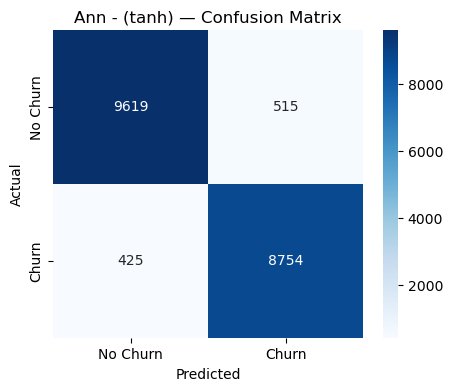

Epoch 1/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 804us/step - accuracy: 0.6528 - loss: 0.6479
Epoch 2/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 822us/step - accuracy: 0.8049 - loss: 0.5247
Epoch 3/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 801us/step - accuracy: 0.8245 - loss: 0.4368
Epoch 4/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 830us/step - accuracy: 0.8267 - loss: 0.4053
Epoch 5/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step - accuracy: 0.8267 - loss: 0.3957
Epoch 6/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.8272 - loss: 0.3924
Epoch 7/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 816us/step - accuracy: 0.8273 - loss: 0.3908
Epoch 8/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 882us/step - accuracy: 0.8278 - loss: 0.3897
Epoch 9/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 794us/step - accuracy: 0.8276 - loss: 0.3887
Epoch 10/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 831us/step - accuracy: 0.8277 - loss: 0.3877
Epoch 11/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 808us/step - accuracy: 0.8282 - loss: 0.38

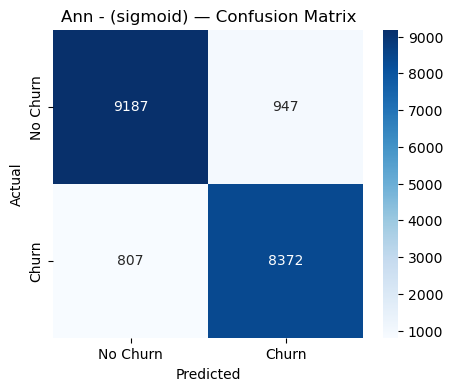

Epoch 1/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 778us/step - accuracy: 0.7955 - loss: 0.4479
Epoch 2/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 798us/step - accuracy: 0.8311 - loss: 0.3829
Epoch 3/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 776us/step - accuracy: 0.8385 - loss: 0.3649
Epoch 4/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.8463 - loss: 0.3449
Epoch 5/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 777us/step - accuracy: 0.8566 - loss: 0.3245
Epoch 6/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.8643 - loss: 0.3064
Epoch 7/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step - accuracy: 0.8710 - loss: 0.2912
Epoch 8/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step - accuracy: 0.8780 - loss: 0.2789
Epoch 9/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 784us/step - accuracy: 0.8812 - loss: 0.2694
Epoch 10/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.8851 - loss: 0.2617
Epoch 11/100
1409/1409 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.8885 - loss: 0.25

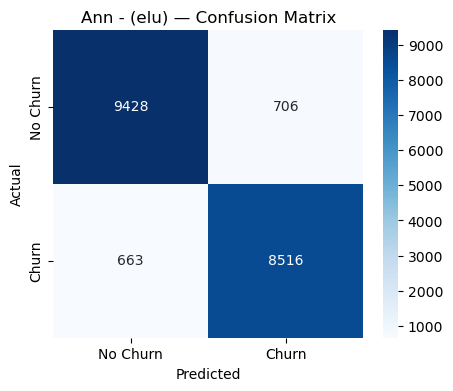

In [34]:
activations = ["relu","tanh","sigmoid","elu"]
for act in activations:
    train_ann(act)

In [35]:
results_table = pd.DataFrame(results_df).T
results_table

,Accuracy,Recall,F1-Score
Logistic Regression,0.828924,0.826016,0.821096
K Nearest Neighbors,0.914824,0.915023,0.910806
SVC,0.952260,0.960671,0.950318
Random Forest,0.998757,0.998148,0.998692
Ann - (relu),0.937037,0.942804,0.934355
Ann - (tanh),0.951328,0.953699,0.949046
Ann - (sigmoid),0.909180,0.912082,0.905179
Ann - (elu),0.929115,0.927770,0.925602


## Multi Model Evaluation and Deployment

### Comparison of All Models' Metrics

Combining all per-model metrics into a single DataFrame for easy comparison.

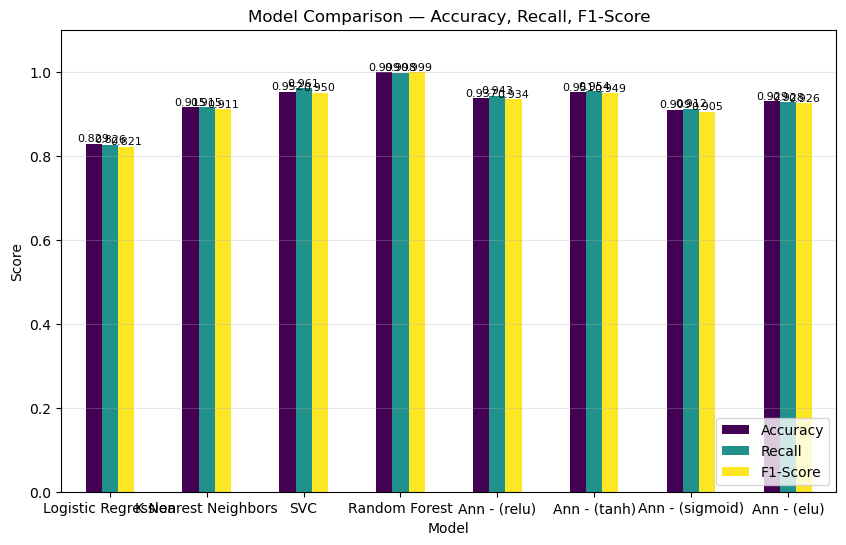

In [36]:
results_table.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Model Comparison — Accuracy, Recall, F1-Score')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=0)
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)

# Annotate each bar with its value
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=8)

plt.show()


### Best Model Selection

From the metrics and the bar chart, **Random Forest** is the most accurate model — it outperforms Logistic Regression, KNN, and SVM across all three metrics (Accuracy, Recall, and F1-Score).

Logistic Regression is the weakest because the underlying relationships in this dataset are non-linear, while KNN and SVM perform better but still cannot match RF's ability to capture complex feature interactions through tree splits.

### Train the Optimal Model on the Entire Dataset

We re-fit the Random Forest on the full dataset (`X`, `y`) using the optimal hyperparameters found earlier. This gives the deployed model access to every available training sample.

In [37]:
final_rf_model = RandomForestClassifier(**grid.best_params_,random_state=42,n_jobs=-1)
final_rf_model.fit(X,y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",4
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

### Export to Joblib

Save the trained final model and the `StandardScaler` to separate `.joblib` files for future use. Although Random Forest itself is scale-invariant, exporting the scaler alongside the model is standard deployment practice — it keeps the full preprocessing record available in case the pipeline is later swapped to a scale-sensitive model (Logistic Regression, KNN, or SVM).

In [38]:
dump(final_rf_model, MODELS_DIR / "final_churn_model.joblib")
dump(scaler, MODELS_DIR / "final_churn_scaler.joblib")

['models\\final_churn_scaler.joblib']

### Import from Joblib

Load the model and preprocessing instances back into fresh variables to confirm the export round-trips correctly.

In [39]:
loaded_model = load(MODELS_DIR / "final_churn_model.joblib")
loaded_scaler = load(MODELS_DIR / "final_churn_scaler.joblib")

print("Model predictions on first 5 rows:")
print(loaded_model.predict(X.head()))

print("\nScaler applied to first 5 rows:")
print(loaded_scaler.transform(X.head()))

Model predictions on first 5 rows:
[1 0 0 0 0]

Scaler applied to first 5 rows:
[[-1.42923701 -0.40458073 -0.12288303 -0.44900053  1.11158799  0.21867067
  -0.75275211 -0.93756559 -0.70487181 -0.70924986  1.37740864 -0.6852067 ]
 [-0.06776366 -0.22924175  1.4643012   0.51564202 -0.46907067  0.16493594
   0.52179968 -0.93756559 -0.70487181  1.40994037  1.37740864 -0.6852067 ]
 [ 0.3621753  -0.28768808 -0.57636424 -1.09209555  1.33739637  0.82894377
   0.63766803  1.06659205  1.41869767 -0.70924986 -0.72600097 -0.6852067 ]
 [-0.49770261 -1.33972197 -0.34962364 -0.12745301 -0.01745391 -1.1861089
   0.290063    1.06659205  1.41869767 -0.70924986 -0.72600097  1.45941364]
 [ 0.79211425  1.52414808  1.01081999  1.15873705 -1.71101675 -0.03081204
   0.290063   -0.93756559 -0.70487181  1.40994037 -0.72600097 -0.6852067 ]]


### Test the Loaded Model

Take a sample from `X`, run it through the loaded scaler, generate a prediction with the loaded model, and compare against the actual label to verify everything works end-to-end.

In [40]:
sample = X.iloc[:5]
scaled_sample = loaded_scaler.transform(sample)
predictions = loaded_model.predict(sample)
print(f"Predicted: {predictions}")
print(f"Actual:    {y.iloc[:5].values}")

Predicted: [1 0 0 0 0]
Actual:    [1 0 0 0 0]
